# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT = Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1")
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [2]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,decoder_transformer,1.187463,3.198793,-0.153641,1.049873
1,decoder_tft,0.973957,3.198601,-0.164324,1.044493
2,lstm_dmn,0.241178,3.030896,-0.047176,1.056171
3,ema_cross_32_96,0.984547,2.029131,-0.177176,0.670538
4,macd_32_96,0.984547,2.029131,-0.177176,0.670538
5,ema_cross_8_24,0.218124,0.718688,-0.350918,0.235547
6,macd_8_24,0.218124,0.718688,-0.350918,0.235547
7,tsmom_78,-0.164255,-0.289819,-0.315492,0.240709
8,macd_16_48,-0.165454,-0.294352,-0.346459,0.392161
9,ema_cross_16_48,-0.165454,-0.294352,-0.346459,0.392161


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,53677,14465.815993,0.014160,0.369045,0.421587,0.209368
1,decoder_transformer,54839,14580.329268,0.019417,0.423521,0.419269,0.157209
2,ema_cross_16_48,3545,4602.000000,-0.000810,0.508479,0.445765,0.045755
3,ema_cross_32_96,2926,3402.000000,0.019076,0.537476,0.419920,0.042604
4,ema_cross_8_24,4697,6870.000000,0.008114,0.494122,0.457088,0.048790
5,long_only,2400,2400.000000,-0.010020,0.959647,0.000000,0.040353
6,lstm_dmn,33852,4618.409085,0.004599,0.178320,0.305264,0.516416
7,macd_16_48,3545,4602.000000,-0.000810,0.508479,0.445765,0.045755
8,macd_32_96,2926,3402.000000,0.019076,0.537476,0.419920,0.042604
9,macd_8_24,4697,6870.000000,0.008114,0.494122,0.457088,0.048790


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.108174,-0.639294,0.367399,-2.775413,-3.220386,-0.146464,-4.364864,0.465416,0.809924,-0.123815,2.094099,-0.870781,2.404852,258,258.0,wf_1_2021-07-01_2021-12-31,long_only
1,0.034204,0.473641,0.369945,1.048096,1.503527,-0.092503,5.120263,0.430366,0.144963,-1.180493,1.513986,-1.590948,0.951625,1112,1846.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,0.000488,0.075384,0.369126,0.196891,0.279894,-0.145484,0.518158,0.432227,0.154048,-1.115711,1.357964,-1.550925,0.875584,909,1486.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,0.059695,0.856029,0.368476,1.678378,2.359140,-0.080466,10.638462,0.447115,0.257876,-0.978503,1.944755,-1.597886,1.217080,612,922.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.039884,-0.272934,0.368436,-0.865108,-1.179146,-0.102795,-2.655141,0.457661,0.234190,-0.960327,1.693125,-1.517155,1.115987,565,840.0,wf_1_2021-07-01_2021-12-31,tsmom_78


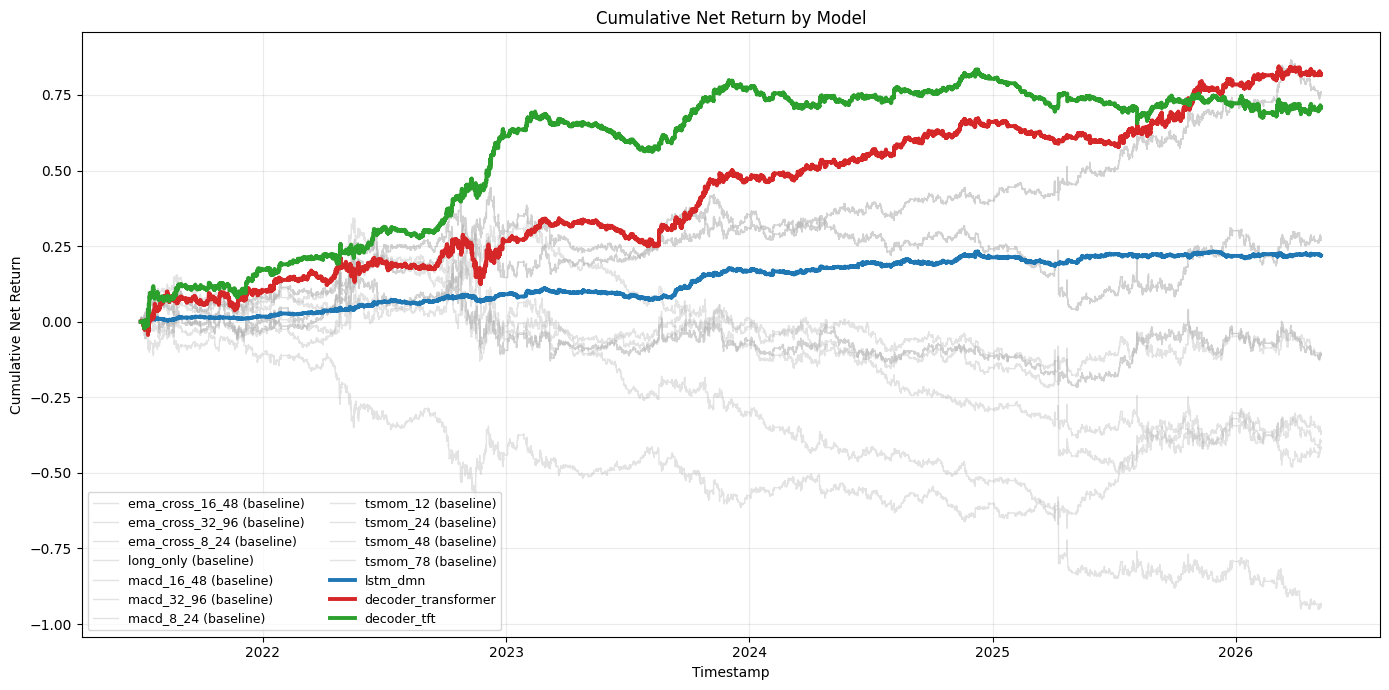

In [3]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',            # blue
    'decoder_transformer': '#d62728', # red
    'decoder_tft': '#2ca02c',         # green
}

plt.figure(figsize=(14, 7))

# plot non-focus first (background)
for model_name, g in pred.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

# plot focus on top
for model_name in focus_models:
    g = pred[pred['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color=focus_colors.get(model_name, None),
        linewidth=2.8, alpha=1.0,
        label=model_name
    )

plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

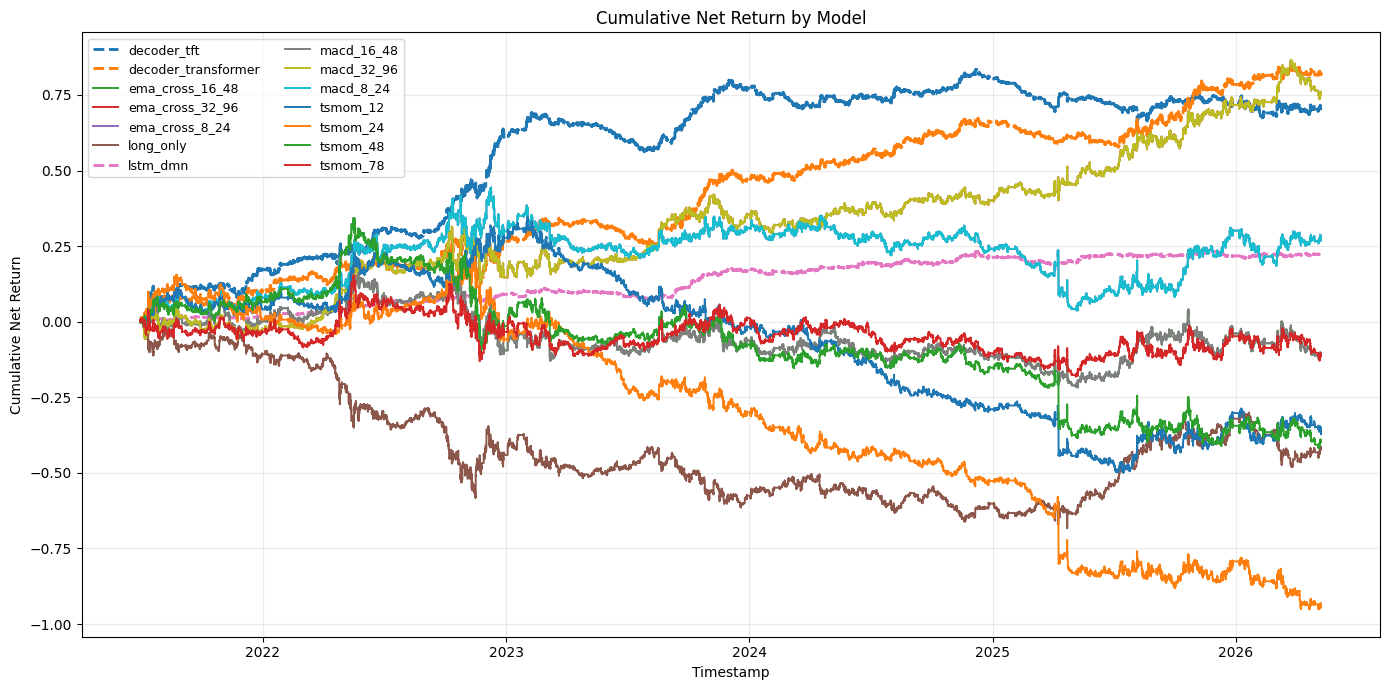

In [6]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

,days,mean_daily_cost,median_daily_cost,p95_daily_cost,max_daily_cost,total_cost
model,,,,,,
tsmom_12,1200,176210.242020,170364.290320,307869.914588,450689.043600,2.114523e+08
decoder_transformer,1200,152941.426643,138559.836435,310127.950950,448689.735675,1.835297e+08
decoder_tft,1200,151629.997881,145802.564757,256851.802488,342261.320012,1.819560e+08
tsmom_24,1200,135155.535124,124342.802480,289295.246976,434285.618080,1.621866e+08
tsmom_48,1200,85378.029603,51268.902320,227688.453852,448462.591680,1.024536e+08
tsmom_78,1200,72305.723192,49270.373480,201150.462824,413178.244880,8.676687e+07
macd_8_24,1200,71931.190612,72628.735440,146651.932872,245762.879760,8.631743e+07
ema_cross_8_24,1200,71931.190612,72628.735440,146651.932872,245762.879760,8.631743e+07
lstm_dmn,1200,48370.990211,48952.420739,89916.505787,147197.833444,5.804519e+07


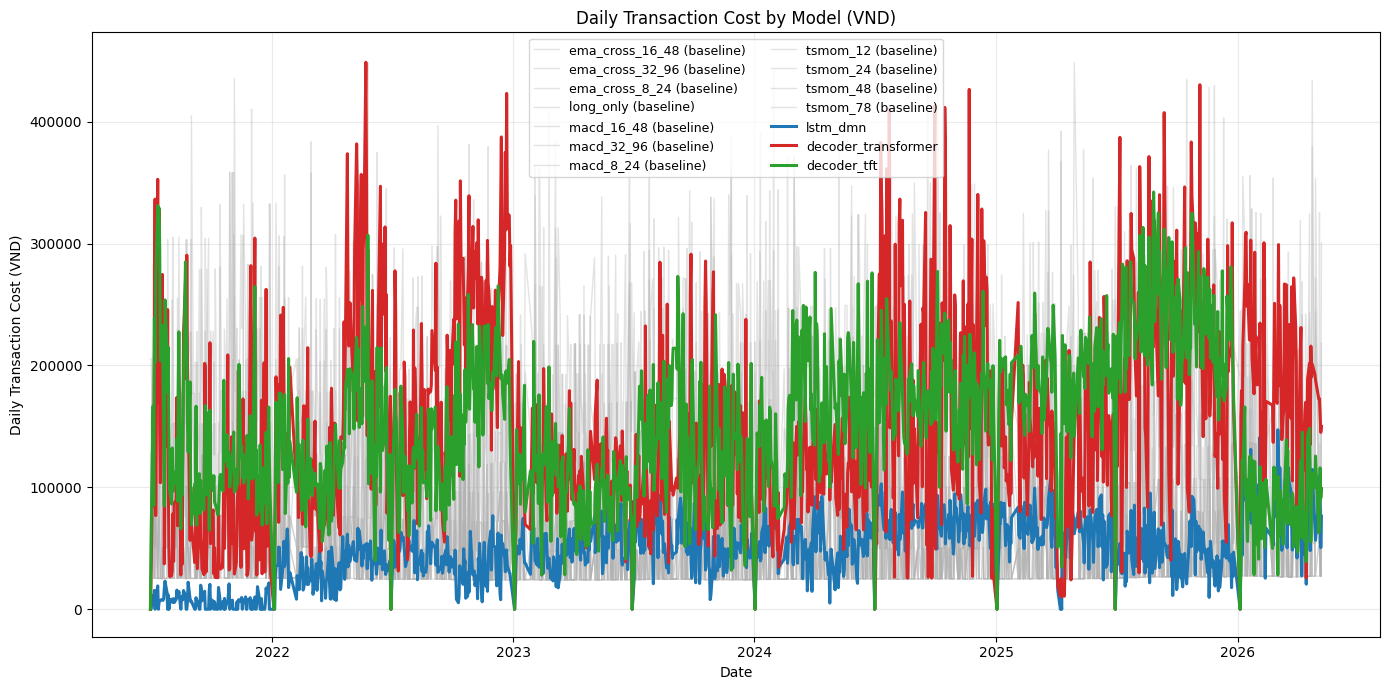

In [4]:
import numpy as np
from pathlib import Path

if 'PROJ' not in globals():
    if 'OUT' in globals():
        PROJ = OUT.parents[1]
    else:
        PROJ = Path.cwd().resolve().parent

px = pd.read_parquet(PROJ / 'data' / 'features' / 'features_5min.parquet')[['timestamp', 'close']]
cost_df = pred[['timestamp', 'model', 'position']].merge(px, on='timestamp', how='left')
cost_df = cost_df.sort_values(['model', 'timestamp']).copy()

contract_multiplier = 100000
margin_rate = 0.1848
transfer_tax_rate = 0.001
fixed_fee_per_side = 5000 + 2700 + 2700

cost_df['prev_pos'] = cost_df.groupby('model')['position'].shift(1).fillna(0.0)
same_sign = np.sign(cost_df['position']) == np.sign(cost_df['prev_pos'])
cost_df['open_size'] = np.where(
    same_sign,
    np.maximum(np.abs(cost_df['position']) - np.abs(cost_df['prev_pos']), 0),
    np.abs(cost_df['position'])
)
cost_df['close_size'] = np.where(
    same_sign,
    np.maximum(np.abs(cost_df['prev_pos']) - np.abs(cost_df['position']), 0),
    np.abs(cost_df['prev_pos'])
)

cost_df['tax_vnd_per_contract'] = (
    margin_rate * contract_multiplier * transfer_tax_rate * cost_df['close'] / 2.0
)
cost_df['open_fixed_cost_vnd'] = cost_df['open_size'] * fixed_fee_per_side
cost_df['open_tax_cost_vnd'] = cost_df['open_size'] * cost_df['tax_vnd_per_contract']
cost_df['open_cost_vnd'] = cost_df['open_fixed_cost_vnd'] + cost_df['open_tax_cost_vnd']
cost_df['close_fixed_cost_vnd'] = cost_df['close_size'] * fixed_fee_per_side
cost_df['close_tax_cost_vnd'] = cost_df['close_size'] * cost_df['tax_vnd_per_contract']
cost_df['tx_cost_vnd'] = cost_df['open_cost_vnd'] + cost_df['close_fixed_cost_vnd'] + cost_df['close_tax_cost_vnd']
cost_df['date'] = cost_df['timestamp'].dt.date

daily_cost = cost_df.groupby(['model', 'date'], as_index=False)['tx_cost_vnd'].sum()
daily_cost_stats = (
    daily_cost.groupby('model')['tx_cost_vnd']
    .agg(
        days='count',
        mean_daily_cost='mean',
        median_daily_cost='median',
        p95_daily_cost=lambda s: s.quantile(0.95),
        max_daily_cost='max',
        total_cost='sum',
    )
    .sort_values('total_cost', ascending=False)
)

display(daily_cost_stats)

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',
    'decoder_transformer': '#d62728',
    'decoder_tft': '#2ca02c',
}

daily_cost = daily_cost.sort_values(['model', 'date'])
daily_cost['date'] = pd.to_datetime(daily_cost['date'])

plt.figure(figsize=(14, 7))
for model_name, g in daily_cost.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

for model_name in focus_models:
    g = daily_cost[daily_cost['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color=focus_colors.get(model_name, None),
        linewidth=2.2, alpha=1.0,
        label=model_name
    )

plt.title('Daily Transaction Cost by Model (VND)')
plt.xlabel('Date')
plt.ylabel('Daily Transaction Cost (VND)')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [5]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png
